In [30]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu

In [31]:
#Load the data
h5_multiome_path = '../data/pbmc10k/10k_PBMC_Multiome_nextgem_Chromium_Controller_filtered_feature_bc_matrix.h5'
#Load the data
mdata = mu.read_10x_h5(h5_multiome_path)
mdata.var_names_make_unique()
mdata


/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from ../data/pbmc10k/10k_PBMC_Multiome_nextgem_Chromium_Controller_filtered_feature_bc_matrix.h5


/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:565: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packag

MuData object with n_obs × n_vars = 10691 × 151780
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	10691 × 36601
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	10691 × 115179
      var:	'gene_ids', 'feature_types', 'genome', 'interval'

In [32]:
#Sepearate the two modalitiees into two different An data objects
print(mdata.mod)
rna = mdata.mod['rna']
atac = mdata.mod['atac']

MuData
├─ rna AnnData (10691 x 36601)
└─ atac AnnData (10691 x 115179)


In [33]:
initial_size = (atac.obs.shape, atac.var.shape, atac.X.shape, rna.obs.shape, rna.var.shape, rna.X.shape)

In [34]:
# Annotate mitochondrial genes
rna.var['mt'] = rna.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
# For each cell compute a set of qc metrics plus the percentage of mitochondrial genes
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

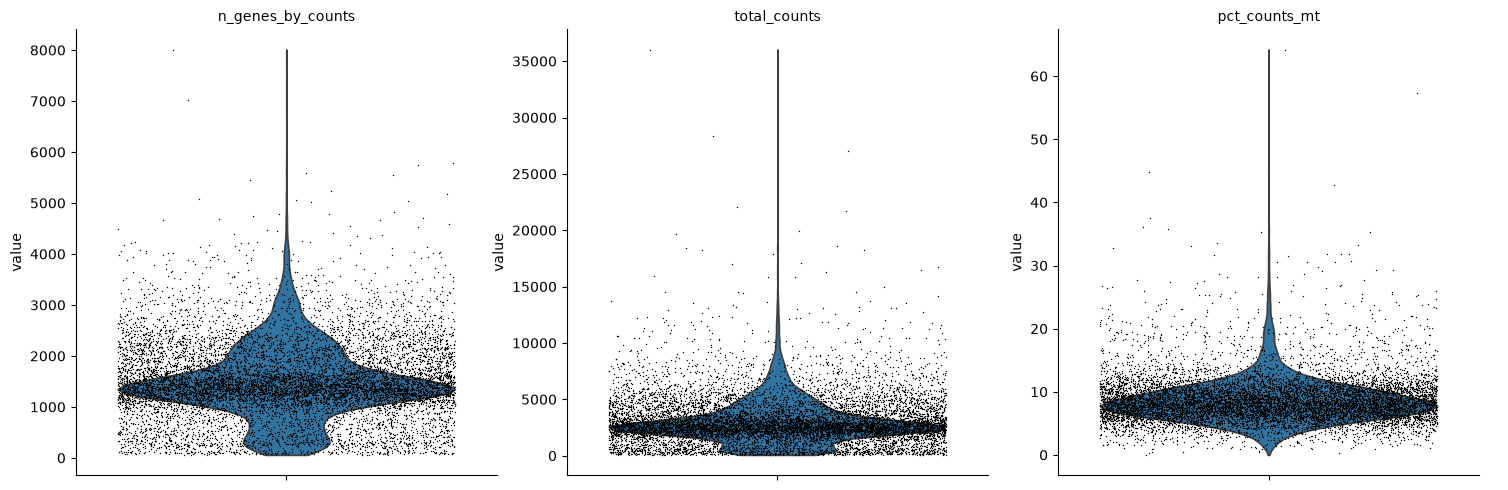

In [35]:
#Plot metrics
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [36]:
# Filter out genes that apear in less than 3 cells
mu.pp.filter_var(rna, 'n_cells_by_counts', lambda x: x >= 3)
# This is analogous to
#   sc.pp.filter_genes(rna, min_cells=3)
# but does in-place filtering and avoids copying the object

In [37]:
# Filter out cells that have more than 200 genes and less than 5000 genes.
# n_genes_by_counts tells how many genes have at least one count in each cell.
mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= 200) & (x < 5000))

# Filter out cells that have more than 15000 counts.
mu.pp.filter_obs(rna, 'total_counts', lambda x: x < 15000)

# Filter out genes that have mitochndrial content more than 20 percent.
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x < 20)

In [38]:
print(atac.obs.shape)
print(atac.var.shape)

print(rna.obs.shape)
print(rna.var.shape)

(10691, 0)
(115179, 4)
(10252, 4)
(25690, 9)


In [39]:
filtered_size = (atac.obs.shape, atac.var.shape, atac.X.shape, rna.obs.shape, rna.var.shape, rna.X.shape)

In [40]:
print(initial_size)
print(filtered_size)

((10691, 0), (115179, 4), (10691, 115179), (10691, 0), (36601, 4), (10691, 36601))
((10691, 0), (115179, 4), (10691, 115179), (10252, 4), (25690, 9), (10252, 25690))


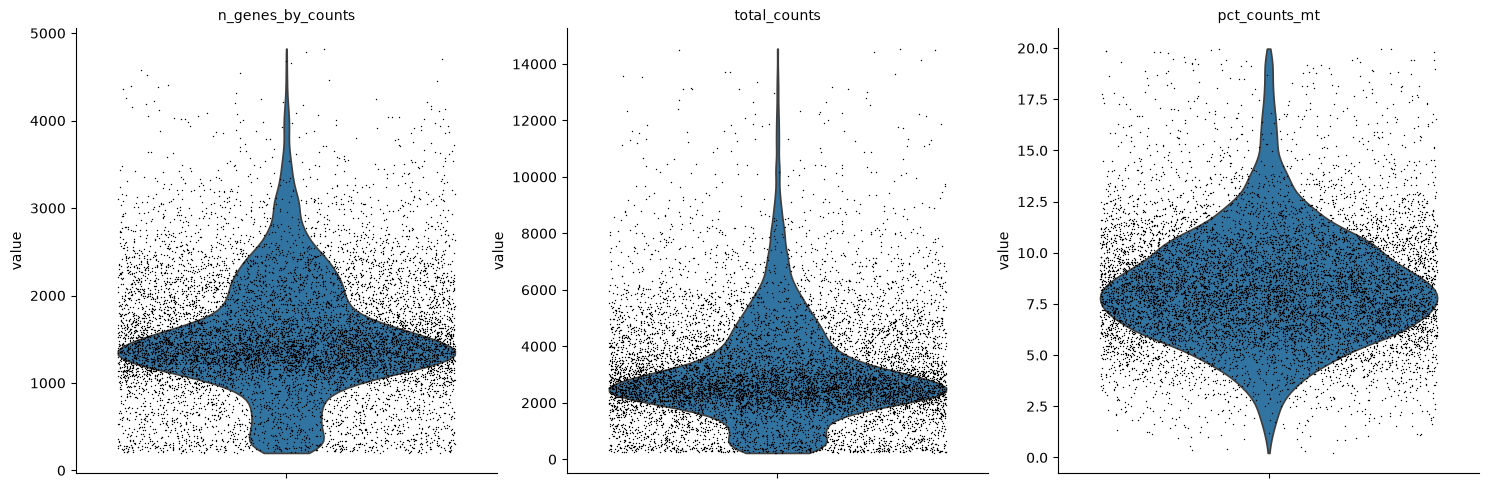

In [41]:
# Plot the qc metrics after the filtering.
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [42]:
# Normalize data so all cells have a sum of 1e4 total reads. This corrects for different sequencing depths of the cesll
sc.pp.normalize_total(rna, target_sum=1e4)

#Log transform the data
sc.pp.log1p(rna)

* X-axis: Mean expression -> The average expression of each gene across all cells.

* Y-axis: Dispersion (or normalized dispersion) -> A measure of how much a gene's expression varies from cell to cell.
High dispersion means the gene is expressed very differently across cells.
Low dispersion means the gene has similar expression in most cells.

4287


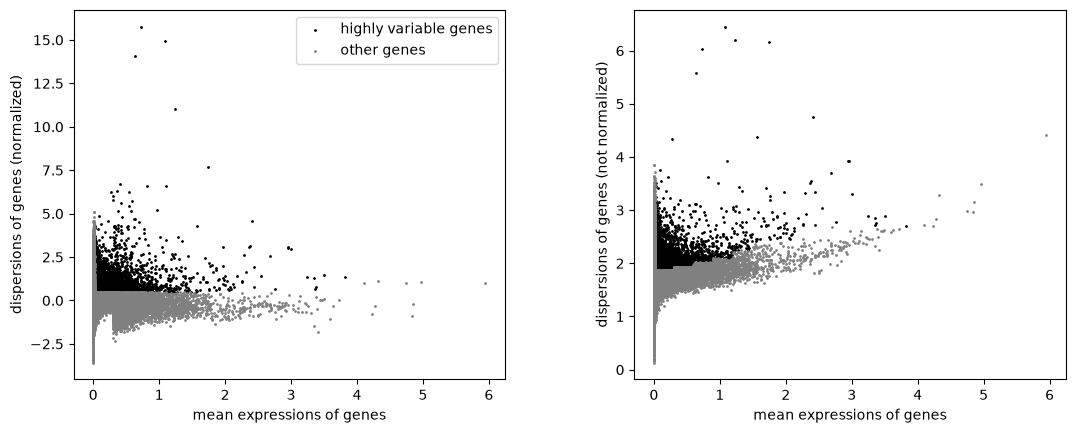

In [43]:
# identify the top variable genes in the range of mean from 0.02 to 4 and minimum dispersion of 0.5
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)

# See how many genes were identified as high variable genes
print(np.sum(rna.var.highly_variable))

# Plot the top variable genes
sc.pl.highly_variable_genes(rna)

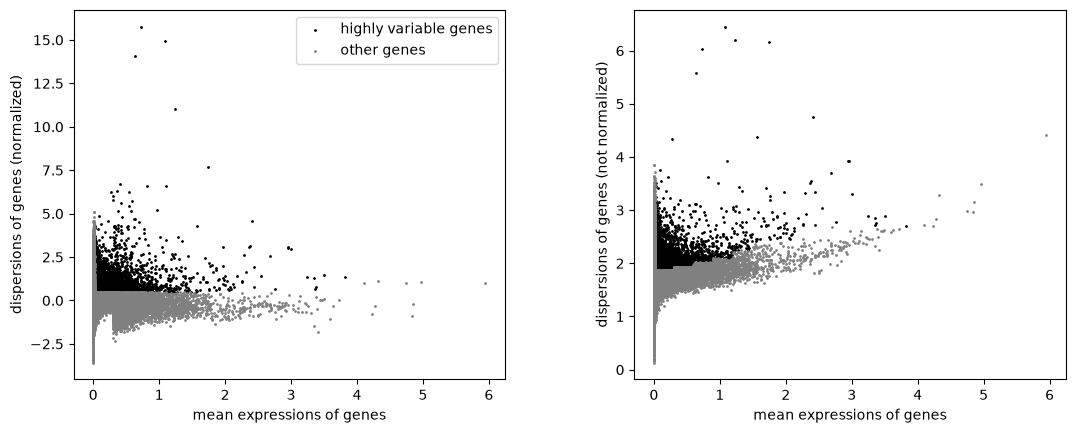

In [44]:
# Plot the top variable genes
sc.pl.highly_variable_genes(rna)

In [45]:
# Initialize a slot in the object to save the data at the current slot
rna.raw = rna

In [46]:
# Scale the data. All scaled values above 10 are clipped to 10
sc.pp.scale(rna, max_value=10)

/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [47]:
# Perform PCA in the data
# The ARPACK SVD solver is an algorithm used to compute a small number of principal components (or singular vectors) 
# from a large matrix without computing the full Singular Value Decomposition (SVD).
sc.tl.pca(rna, svd_solver='arpack')

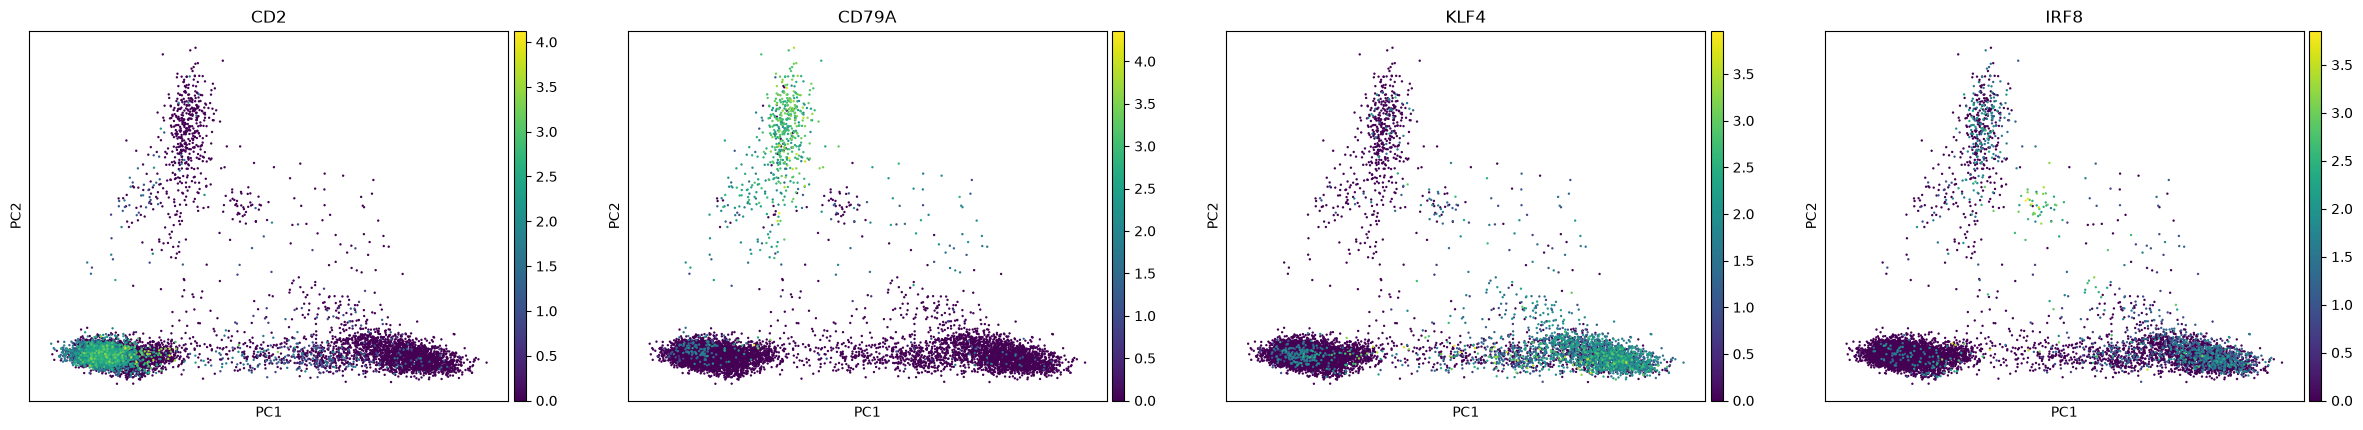

In [48]:
# Plot the first two principal components and color each cell based on the expression value of the corresponding gene. 
sc.pl.pca(rna, color=['CD2', 'CD79A', 'KLF4', 'IRF8'])

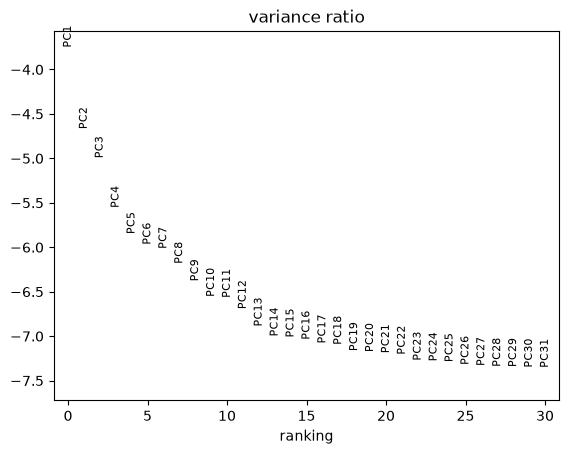

In [49]:
#Plot the variance of each principal component.
# The y axis is the log transformed explained variance.
sc.pl.pca_variance_ratio(rna, log=True)

In [50]:
#From the first 20 principle components compute the neighbor graph 
sc.pp.neighbors(rna, n_neighbors=10, n_pcs=20)

In [51]:
# Perform clustering on the data
sc.tl.leiden(rna, resolution=.5)

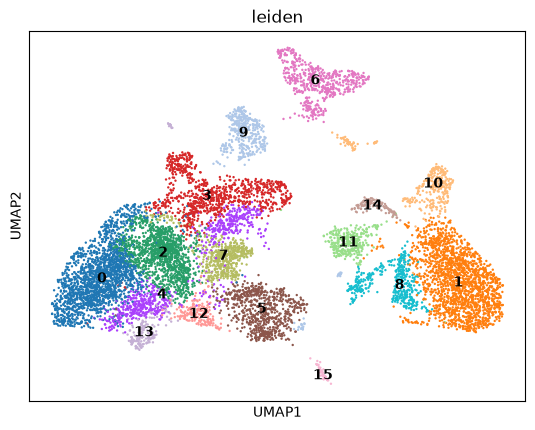

In [52]:
# Compute the UMAP embedings of the data
sc.tl.umap(rna, spread=1., min_dist=.5, random_state=11)

# Plot the first two dimensions
sc.pl.umap(rna, color="leiden", legend_loc="on data")

In [53]:
# identify marker genes.
# These are genes that are differentially expressed in each cluster. 
# A t-test is performed each type per cluster against the rest of the cells.
sc.tl.rank_genes_groups(rna, 'leiden', method='t-test')

In [54]:
# Plot the top 10 most significant marker genes of each cluster.
result = rna.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.set_option('display.max_columns', 50)
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(10)

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,5_n,5_p,6_n,6_p,7_n,7_p,8_n,8_p,9_n,9_p,10_n,10_p,11_n,11_p,12_n,12_p,13_n,13_p,14_n,14_p,15_n,15_p
0,INPP4B,0.0,NAMPT,0.0,BCL11B,2.901671e-300,CCL5,0.000000e+00,IL32,3.925173e-70,PLCG2,9.035725e-223,BANK1,0.000000e+00,BACH2,3.143856e-190,LYZ,0.000000e+00,GNLY,6.966138e-230,LYN,1.834545e-173,LYZ,7.339806e-160,RPS29,1.185982e-09,SKAP1,2.715682e-31,PLCG2,3.226241e-38,TCF4,4.922330e-47
1,IL7R,0.0,LYZ,0.0,BACH2,4.621360e-280,NKG7,4.029518e-178,BCL11B,1.166290e-58,ID2,1.046668e-63,CD74,0.000000e+00,LEF1,4.333206e-140,PSAP,8.432077e-206,NKG7,7.691781e-165,PSAP,7.937290e-165,FCN1,8.230269e-148,RPL23A,6.652571e-08,IKZF2,1.485995e-29,SAT1,9.930774e-29,CD74,1.658492e-51
2,LTB,0.0,PLXDC2,0.0,LEF1,1.401165e-273,IL32,7.879991e-179,PRKCH,3.062090e-54,CROCC,2.599581e-59,HLA-DRA,0.000000e+00,NELL2,1.724636e-123,FTH1,4.699877e-224,CD247,3.568912e-141,CTSS,1.366680e-142,DPYD,1.047283e-147,RPS27,1.539864e-06,CYTOR,4.291067e-27,ATP2B1-AS1,5.639749e-24,AFF3,3.346488e-41
3,ARHGAP15,0.0,FCN1,0.0,MALAT1,2.063676e-249,PRKCH,3.242416e-173,IL7R,8.916034e-54,HIST1H4C,4.061432e-46,AFF3,0.000000e+00,PDE3B,1.375943e-120,PLXDC2,3.380212e-187,PRF1,5.142246e-118,CD74,2.419769e-155,PLXDC2,7.427798e-134,RPS27A,1.355734e-05,TOX,1.189315e-24,ID2,2.819188e-13,FCHSD2,9.974467e-40
4,RORA,0.0,VCAN,0.0,FHIT,2.421285e-213,DUSP2,3.033159e-127,SKAP1,6.024854e-53,SLC38A2,9.518017e-46,CD79A,3.784979e-275,THEMIS,5.517324e-118,CST3,3.705556e-178,GZMB,1.938020e-101,SAT1,1.894955e-133,NEAT1,7.776510e-147,RPS28,6.009786e-05,IL32,1.796924e-24,TNFAIP2,2.696052e-12,HLA-DRA,8.189205e-39
5,IL32,0.0,NEAT1,0.0,CAMK4,3.752616e-194,HLA-C,3.538880e-131,SYNE2,4.227290e-52,TEX14,5.337456e-38,MS4A1,2.929065e-263,MALAT1,4.469727e-116,CD74,7.990249e-175,KLRD1,1.857249e-99,NEAT1,2.221610e-140,PSAP,2.955906e-139,RPL13,6.336977e-05,RTKN2,4.858173e-22,AC012447.1,3.771214e-11,PLD4,1.617901e-35
6,CD69,0.0,ARHGAP26,0.0,TSHZ2,1.511980e-185,GZMA,1.414610e-115,THEMIS,6.372678e-50,AC012447.1,3.352773e-36,RALGPS2,4.239159e-264,MAML2,8.513915e-108,TYROBP,4.188195e-162,CTSW,1.178496e-96,MTSS1,3.868764e-116,ARHGAP26,1.170281e-128,RPL39,1.710390e-04,CASK,1.665939e-20,AL691403.1,1.012234e-10,RHEX,4.398295e-34
7,JUN,0.0,PSAP,0.0,MAML2,7.030604e-185,CTSW,7.262050e-111,ARHGAP15,1.163032e-48,JUN,2.942686e-32,HLA-DPB1,2.412152e-250,FOXP1,3.380178e-90,MNDA,2.950452e-151,SPON2,7.109603e-83,LST1,5.888840e-116,NAMPT,3.145843e-124,RPS8,7.461188e-04,LINC02694,5.516752e-20,RGS2,1.122034e-10,PLAC8,2.577483e-34
8,TRAC,0.0,DPYD,0.0,PRKCA,2.042120e-173,GZMK,2.427965e-109,INPP4B,6.097954e-45,MALAT1,2.699515e-29,HLA-DPA1,4.644845e-246,BCL11B,2.543456e-87,CTSS,2.450239e-149,AOAH,1.434109e-85,CST3,3.049491e-119,VCAN,6.174897e-117,RPS12,8.231693e-04,STAM,1.270259e-19,HLA-DRA,2.208788e-10,ITM2C,8.546413e-32
9,JUNB,0.0,GAB2,0.0,FOXP1,2.262621e-179,A2M,1.743418e-102,MALAT1,2.916905e-44,ZAP70,1.794547e-25,HLA-DQB1,2.707659e-206,LINC02446,1.596007e-71,GRN,3.481249e-142,GZMA,7.575471e-80,FCER1G,1.866553e-115,ZEB2,8.174351e-113,RPL30,8.873719e-04,TRAC,2.820830e-19,CSF3R,6.938828e-10,APP,6.923728e-31


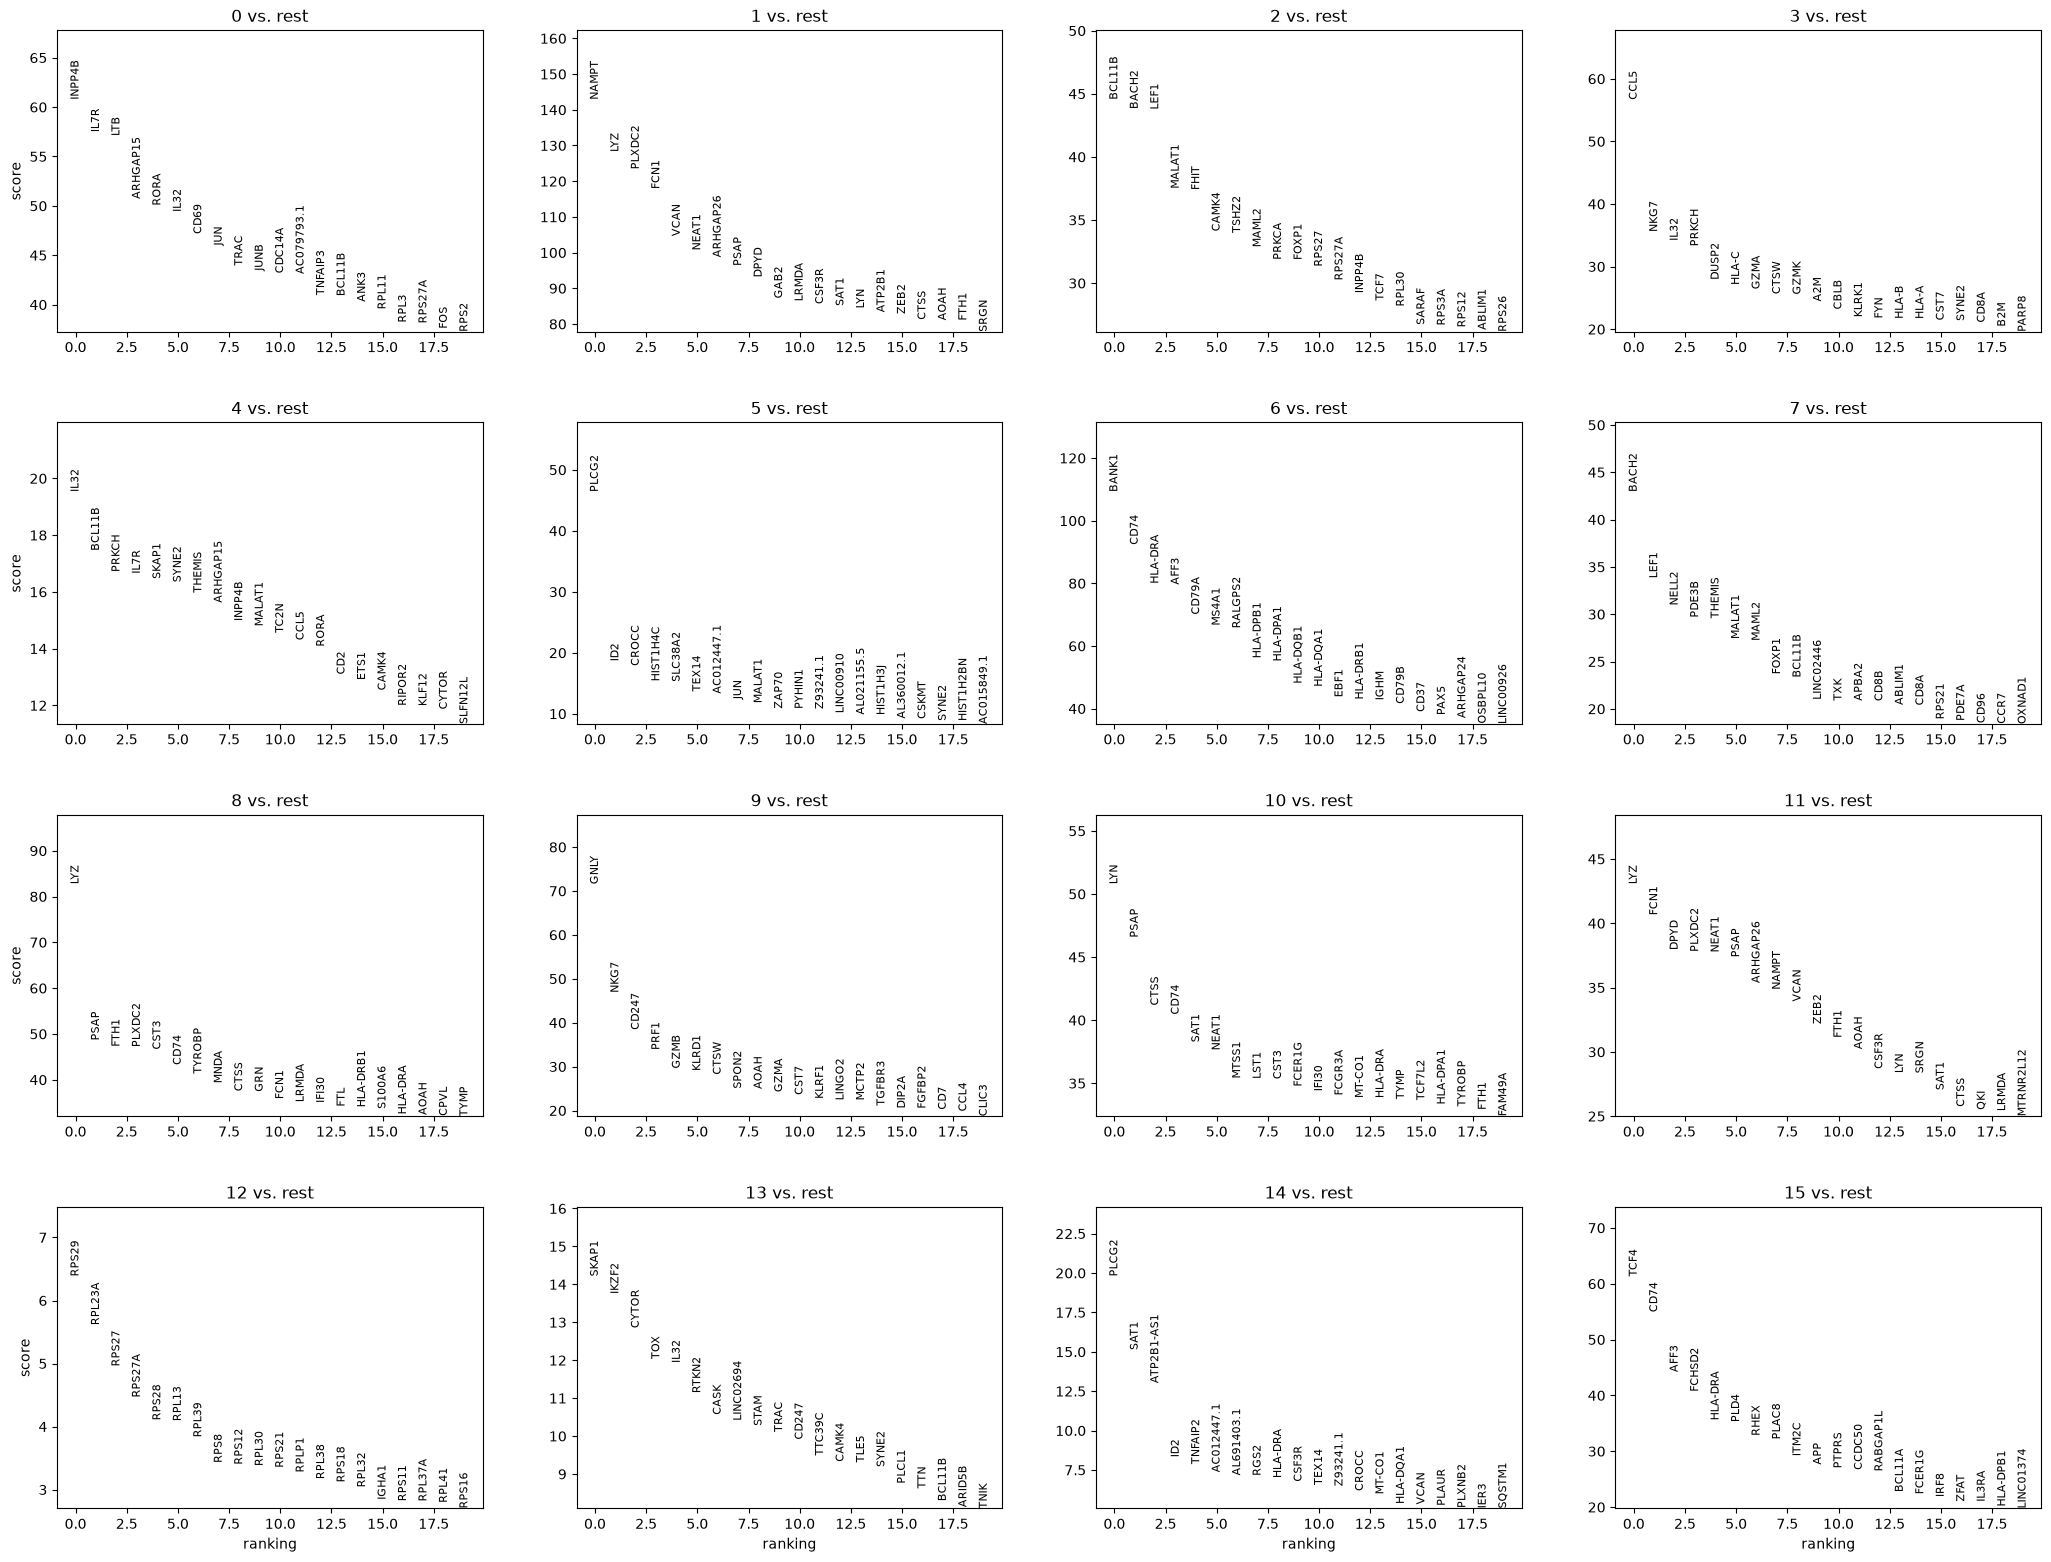

In [55]:
# Plot the top 20 marker genes per cluster
sc.pl.rank_genes_groups(rna, n_genes=20, sharey=False)

In [56]:
# After examining the different genes sets I can see that some clusters have marker genes of different cell types, other 
# have marker genes of proliferatng genes or others may have markers of ribosomal genes. I can remove these clusters from the data.
mu.pp.filter_obs(rna, "leiden", lambda x: ~x.isin(["5", "12", "14"]))


In [59]:
# After examining the marker genes I can manually assign cwll types to clusters.
new_cluster_names = {
    "0": "CD4+ memory T",
    "1": "CD14+ classical monocyte",
    "2": "Naive T cell 1",
    "3": "CD8+ cytotoxic T",
    "4": "Activated CD4+ T",
    "6": "Memory B cell",
    "7": "Naive T cell 2",
    "8": "Monocyte/macrophage",
    "9": "Cytotoxic NK cell",
    "10": "Activated monocyte",
    "11": "Inflammatory monocyte",
    "13": "Regulatory T-like cell",
    "15": "Plasmacytoid dendritic cell",
}

rna.obs['celltype'] = rna.obs.leiden.astype("str").values
rna.obs.celltype = rna.obs.celltype.astype("category")
rna.obs.celltype = rna.obs.celltype.cat.rename_categories(new_cluster_names)

In [61]:
# # Reorder the clusters
# rna.obs.celltype.cat.reorder_categories([
#     'CD4+ naïve T', 'CD4+ memory T', 'MAIT',
#     'CD8+ naïve T', 'CD8+ activated T', 'NK',
#     'naïve B', 'memory B',
#     'CD14 mono', 'intermediate mono', 'CD16 mono',
#     'mDC', 'pDC'], ordered=True)

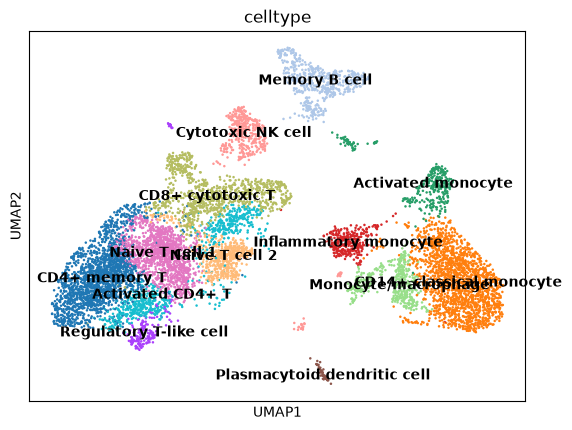

In [62]:
# Plo the clusters but this time with the cell type name instead of the cluster number.
sc.pl.umap(rna, color="celltype", legend_loc="on data")

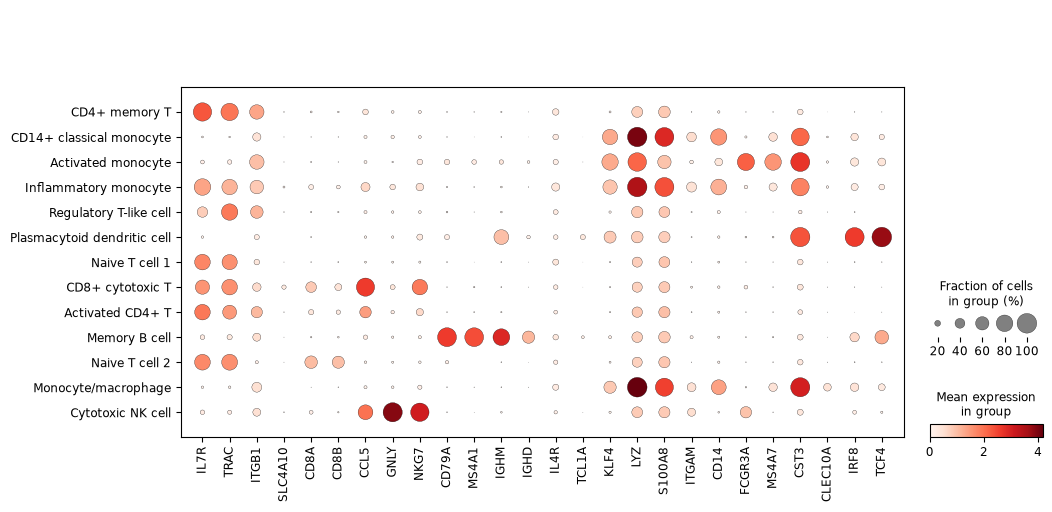

In [63]:
#Plo the marker genes
marker_genes = ['IL7R', 'TRAC',
                'ITGB1', # CD29
                'SLC4A10',
                'CD8A', 'CD8B', 'CCL5',
                'GNLY', 'NKG7',
                'CD79A', 'MS4A1', 'IGHM', 'IGHD',
                'IL4R', 'TCL1A',
                'KLF4', 'LYZ', 'S100A8', 'ITGAM', # CD11b 
                'CD14', 'FCGR3A', 'MS4A7', 
                'CST3', 'CLEC10A', 'IRF8', 'TCF4']

sc.pl.dotplot(rna, marker_genes, groupby='celltype')

In [64]:
# Save the modified object
mdata.write("../data/pbmc10k/pbmc10k.h5mu")

/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
